# **Clasificación de cadenas de ADN**

**Fundamentos de Procesamiento de Lenguaje Natural**

Competencia Final

Objetivo: El objetivo es diseñar un modelo capaz de detectar, en una secuencia de ADN, si esta ha sido mutada
de forma artificial.

Presentado por - Grupo 12:

*   Diego Andres Burbano Arturo
*   Juan Manuel Arenas Pardo
*   Omar Dario Díaz Hernandez
*   Ana Milena Sánchez Villamil
*   Miguel Urueña Riobo

**1. Carga de librerias**

In [1]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 75.0 MB/s eta 0:00:00


In [108]:
# =====================================================
# Standard libraries
# =====================================================
import os
import time
import warnings
import logging
from collections import Counter, defaultdict

# =====================================================
# Data manipulation
# =====================================================
import numpy as np
import pandas as pd

# =====================================================
# Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# Machine Learning
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import OneHotEncoder

# Text / sequence vectorization
from sklearn.feature_extraction.text import CountVectorizer

# =====================================================
# Sparse matrices
# =====================================================
from scipy.sparse import csr_matrix, hstack

# =====================================================
# Models
# =====================================================
import lightgbm as lgb
# CONFIGURACIÓN DE LOGS
logging.basicConfig(
    format='%(asctime)s : %(levelname)s : %(message)s',
    level=logging.INFO
)
import joblib
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print(f"Versión de Gensim: {gensim.__version__}")


Versión de Gensim: 4.4.0


**2. Carga, evaluación y preparación de datos**

In [4]:
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Kaggle_DNA/Data/'
path = '/content/drive/MyDrive/Kaggle_DNA/Modelos/'

TRAIN_DATA = os.path.join(BASE_PATH, 'train.csv')
EVAL_DATA = os.path.join(BASE_PATH, 'eval.csv')


Mounted at /content/drive


In [5]:
df_train = pd.read_csv(TRAIN_DATA)
df_eval = pd.read_csv(EVAL_DATA)
col_adn = 'sequence'
col_label = 'is_mutated'

In [73]:
#EXPLORACION DEL CONJUNTO DE DATOS
print("ENCABEZADO DE CONJUNTO DE ENTRENAMIENTO")
display(df_train.head())

ENCABEZADO DE CONJUNTO DE ENTRENAMIENTO


,id,sequence,original_label,is_mutated
0,4199,GTCTGTTATTGTTTATTGATGGCAGACACTCGCGTCTTACGACGAA...,Leviviricetes,1
1,42083,GATTAAGACCAACTTTAGATAGAATTTCAGAGAATTCATAACGTTG...,Malgrandaviricetes,1
2,15249,AGCCCACTTATCAATCGTGAGCGTGACCTTGTATGTCTGCGCGAGA...,Faserviricetes,1
3,44043,TCATGGAGGACGACGGGATTTTGACGGCTGTGAGGACCGCCGACTG...,Caudoviricetes,1
4,36019,GCGCTTTAATCGATTAAAATCAACAAAGAGCTCACTAACATTAGTA...,Leviviricetes,0



--- ANÁLISIS DE LONGITUD ---
count     46671.000000
mean       7586.727025
std        8638.147588
min         436.000000
25%        4170.000000
50%        4993.000000
75%        7462.000000
max      129572.000000
Name: longitud, dtype: float64


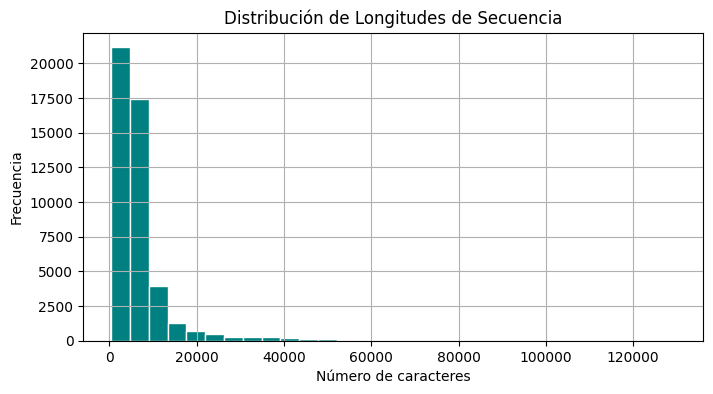


RESULTADO: Los datos son DISPERSOS (hay 9939 longitudes diferentes).


In [74]:
# REVISION DE LONGITUD DE SECUENCIAS DEL ADN (Dispersión vs Homogeneidad)
df_train['longitud'] = df_train[col_adn].str.len()
print("\n--- ANÁLISIS DE LONGITUD ---")
print(df_train['longitud'].describe())

# Visualización rápida
plt.figure(figsize=(8, 4))
df_train['longitud'].hist(bins=30, color='teal', edgecolor='white')
plt.title('Distribución de Longitudes de Secuencia')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.show()

if df_train['longitud'].nunique() == 1:
    print(f"\nRESULTADO: Los datos son HOMOGÉNEOS (todas miden {df_train['longitud'].iloc[0]} letras).")
else:
    print(f"\nRESULTADO: Los datos son DISPERSOS (hay {df_train['longitud'].nunique()} longitudes diferentes).")

A partir de la gráfica de distribución de longitudes podemos concluir:

1. Distribución fuertemente sesgada a la derecha (right-skewed)
La mayoría de las secuencias se concentran en longitudes relativamente cortas (principalmente por debajo de ~10k caracteres), mientras que existe una cola larga con pocas secuencias extremadamente largas que alcanzan más de 100k caracteres.
Esto indica una alta variabilidad en la longitud de las secuencias del dataset.

2. Necesidad de métodos independientes de la longitud de la secuencia
Debido a esta gran variabilidad, utilizar representaciones que dependan directamente de la longitud podría introducir sesgos en el modelo. Por esta razón, se optó por representaciones basadas en frecuencias y estadísticas agregadas, que normalizan la información independientemente del tamaño de la secuencia.

In [6]:
# FUNCION PARA LIMPIEZA
def clean_and_prepare(df):
    cols_to_drop = [col_adn]
    if col_label in df.columns:
        cols_to_drop.append(col_label)

    df = df.dropna(subset=cols_to_drop)
    df = df.drop_duplicates(subset=[col_adn])
    df[col_adn] = df[col_adn].str.upper()
    return df

df_train = clean_and_prepare(df_train)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train[col_adn].values,
    df_train[col_label].values,
    test_size=0.20,
    stratify=df_train[col_label].values,
    random_state=42
)

PREPARACION DE DATOS - CARGA original_label (familia)

In [8]:
idx_train, idx_val = train_test_split(
    np.arange(len(df_train)),
    test_size=0.20,
    stratify=df_train[col_label].values,
    random_state=42
)

X_train_seq = df_train[col_adn].values[idx_train]
X_val_seq = df_train[col_adn].values[idx_val]

y_train_seq = df_train[col_label].values[idx_train]
y_val_seq = df_train[col_label].values[idx_val]

# CODIFICACION DE LA CLASE TAXONOMICA
family_train = df_train["original_label"].values[idx_train]
family_val = df_train["original_label"].values[idx_val]

Se codifica la clase taxonómica original a la que pertenece la secuencia que se encuentra en el campo original_label, la cual la identificaremos como family.

In [9]:
# CODIFICACION DE VARIABLE ORIGINAL_LABEL (FAMILIA DE VIRUS)

ohe = OneHotEncoder(sparse_output=True, handle_unknown="ignore")

family_train_ohe = ohe.fit_transform(family_train.reshape(-1,1))
family_val_ohe = ohe.transform(family_val.reshape(-1,1))

**3. Construcción de modelo: creación de matriz de características**

3.1 COUNTVECTORIZER (k-mers de 3 a 6)

Se transforma cada secuencia en un vector de frecuencias de k-mers (subcadenas) de longitud 3 a 6, capturando micro-patrones locales del ADN que pueden reflejar mutaciones.

In [11]:
# VECTORIZACION
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    analyzer="char",
    ngram_range=(3,6),
    min_df=5,
    max_df=0.95
)

X_train_counts = vectorizer.fit_transform(X_train_seq)
X_val_counts = vectorizer.transform(X_val_seq)


X_train_counts = vectorizer.fit_transform(X_train_seq)
X_val_counts = vectorizer.transform(X_val_seq)

In [ ]:
#ALMACENAR MATRIZ COUNTVECTORIZER SEGMENTADA

# Guardar matrices CountVectorizer
save_npz(os.path.join(path, "X_train_counts.npz"), X_train_counts)
save_npz(os.path.join(path, "X_val_counts.npz"), X_val_counts)

# Guardar el vectorizer
with open(os.path.join(path, "vectorizer.pkl"), "wb") as f:
    pickle.dump(vectorizer, f)


In [ ]:
#RECUPERAR MATRIZ TFIDF SEGMENTADA

X_train_counts = load_npz(os.path.join(path, "X_train_counts.npz"))
X_val_counts = load_npz(os.path.join(path, "X_val_counts.npz"))

with open(os.path.join(path, "vectorizer.pkl"), "rb") as f:
    vectorizer = pickle.load(f)


3.2 Dinucleotidos (DINUCLEOTIDES FEATURES)

Se calculan las frecuencias normalizadas de los 16 posibles dinucleótidos (AA, AC, …, TT) en cada secuencia para capturar patrones locales de composición que pueden alterarse por mutaciones.

In [13]:
#GENERACION DE MATRIZ DE 16 NUCLEOTIDOS X 2

dinucs = [''.join(p) for p in itertools.product("ACGT", repeat=2)]

In [99]:
dinucs

['AA',
 'AC',
 'AG',
 'AT',
 'CA',
 'CC',
 'CG',
 'CT',
 'GA',
 'GC',
 'GG',
 'GT',
 'TA',
 'TC',
 'TG',
 'TT']

In [14]:
def dinucleotide_freq(seq):

    seq = seq.upper()

    counts = dict.fromkeys(dinucs, 0)

    for i in range(len(seq) - 1):
        pair = seq[i:i+2]
        if pair in counts:
            counts[pair] += 1

    total = sum(counts.values())

    if total == 0:
        return [0]*16

    return [counts[d]/total for d in dinucs]

In [15]:
dinuc_train = np.array([dinucleotide_freq(s) for s in X_train_seq])
dinuc_val = np.array([dinucleotide_freq(s) for s in X_val_seq])

In [17]:
dinuc_train_sparse = csr_matrix(dinuc_train)
dinuc_val_sparse = csr_matrix(dinuc_val)

3.3 RARE K-MER SCORE

Se calculan las frecuencias normalizadas de los 16 posibles dinucleótidos (AA, AC, …, TT) en cada secuencia para capturar patrones locales de composición que pueden alterarse por mutaciones.

In [19]:
#RARE K-MER SCORE
#Función para extaer k-mers
def get_kmers(seq, k=5):
    return [seq[i:i+k] for i in range(len(seq)-k+1)]
from collections import Counter, defaultdict

# Contar K-mers por familia
from collections import Counter, defaultdict

k = 5

family_kmer_counts = defaultdict(Counter)
family_kmer_total = defaultdict(int)

for seq, fam in zip(X_train_seq, family_train):
    kmers = get_kmers(seq, k)
    family_kmer_counts[fam].update(kmers)
    family_kmer_total[fam] += len(kmers)

In [20]:
#CALCULAR RARE SCORE
family_kmer_score = {}
for fam in family_kmer_counts:
    total = family_kmer_total[fam]
    scores = {}
    for km, count in family_kmer_counts[fam].items():
        p = (count + 1) / (total + 1)
        scores[km] = -np.log(p)
    family_kmer_score[fam] = scores

In [44]:
def rare_kmer_score(seq, fam):
    kmers = get_kmers(seq, k)
    scores = family_kmer_score[fam]

    vals = [scores.get(km, 10) for km in kmers]

    mean_score = np.mean(vals)
    std_score = np.std(vals)
    max_score = np.max(vals)

    return [mean_score, std_score, max_score]

In [45]:
rare_kmer_train = np.array([
    rare_kmer_score(seq, fam)
    for seq, fam in zip(X_train_seq, family_train)
])

In [46]:
rare_kmer_val = np.array([
    rare_kmer_score(seq, fam)
    for seq, fam in zip(X_val_seq, family_val)
])

In [47]:
rare_kmer_train = csr_matrix(rare_kmer_train)
rare_kmer_val   = csr_matrix(rare_kmer_val)

3.4 CONSTRUCCION DE MATRIZ PRINCIPAL

Se combinan las matrices generadas (k-mers con CountVectorizer, familia viral codificada, frecuencias de dinucleótidos y rare k-mer score) en una sola matriz de características que será utilizada como entrada del modelo.

**Feature Engineering Strategy**

El modelo utiliza un stack de cuatro tipos de features complementarios:

1. k-mer representation (CountVectorizer)
Captura patrones locales de subsecuencias en el DNA.

2. Family encoding
Introduce información contextual sobre la familia biológica de la secuencia.

3. Dinucleotide frequencies
Representan patrones estructurales globales del DNA.

4. Rare k-mer statistics (mean, std, max)
Detectan subsecuencias poco frecuentes que pueden indicar mutaciones.

Se verifican las dimensiones de cada bloque de features para asegurar
consistencia antes de concatenar la matriz final.

In [101]:
#VERIFICAR TIPOS Y DIMENSIONES DE LOS INPUTS DE LAS MATRICES
def describe_features(title, **features):
    print(f"\n-- {title.upper()} --")
    for name, value in features.items():
        if hasattr(value, "shape"):
            print(f"{name}: {type(value)} - {value.shape}")
        else:
            print(f"{name}: {type(value)} - {value}")

describe_features(
    "Set de Entrenamiento",
    X_train_counts=X_train_counts,
    family_train_ohe=family_train_ohe,
    dinuc_train_sparse=dinuc_train_sparse,
    rare_kmer_train=rare_kmer_train)

describe_features(
    "Set de Validación",
    X_val_counts=X_val_counts,
    family_val_ohe=family_val_ohe,
    dinuc_val_sparse=dinuc_val_sparse,
    rare_kmer_val=rare_kmer_val
)


-- SET DE ENTRENAMIENTO --
X_train_counts: <class 'scipy.sparse._csr.csr_matrix'> - (37336, 7137)
family_train_ohe: <class 'scipy.sparse._csr.csr_matrix'> - (37336, 4)
dinuc_train_sparse: <class 'scipy.sparse._csr.csr_matrix'> - (37336, 16)
rare_kmer_train: <class 'scipy.sparse._csr.csr_matrix'> - (37336, 3)

-- SET DE VALIDACIÓN --
X_val_counts: <class 'scipy.sparse._csr.csr_matrix'> - (9335, 7137)
family_val_ohe: <class 'scipy.sparse._csr.csr_matrix'> - (9335, 4)
dinuc_val_sparse: <class 'scipy.sparse._csr.csr_matrix'> - (9335, 16)
rare_kmer_val: <class 'scipy.sparse._csr.csr_matrix'> - (9335, 3)


In [102]:
# CONSTRUCCIÓN DE MATRIZ PRINCIPAL

X_train_final = hstack([
    X_train_counts, # Representación CounterVectorizer
    family_train_ohe, # Representación codificada campo 'original_label'
    dinuc_train_sparse, # Dinucleotidos
    rare_kmer_train # Rare k-mer score
])

X_val_final = hstack([
    X_val_counts,
    family_val_ohe,
    dinuc_val_sparse,
    rare_kmer_val
])

In [103]:
# REVISION DE DIMENSIONES MATRIZ PRINCIPAL
print(X_train_final.shape)
print(X_val_final.shape)

(37336, 7160)
(9335, 7160)


**4. Construcción de Clasificador Binario (LGBM)**

Se entrena un modelo LightGBM sobre la matriz final de características para aprender patrones no lineales entre la composición de k-mers y la presencia de mutaciones en las secuencias.

Se utiliza LightGBM debido a su capacidad para manejar matrices de alta
dimensionalidad y features dispersos provenientes de representaciones
de k-mers.

In [104]:
#MEJORES PARAMETROS
lgbm = LGBMClassifier(
    n_estimators=2100,
    learning_rate=0.02,
    num_leaves=24,
    min_child_samples=80,
    feature_fraction=0.5,
    bagging_fraction=0.8,
    bagging_freq=5,
    lambda_l2=15,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

lgbm.fit(X_train_final, y_train_seq)

pred = lgbm.predict(X_val_final)

f1_score(y_val_seq, pred, average="macro")

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 18679, number of negative: 18657
[LightGBM] [Info] Total Bin

0.7703198204626114

In [105]:
y_train_seq_pred = lgbm.predict(X_train_final)
pred = lgbm.predict(X_val_final)

f1_t1 = f1_score(y_train_seq, y_train_seq_pred, average='macro')
f1_v1 = f1_score(y_val_seq, pred, average='macro')

gap1 = f1_t1 - f1_v1

nombre1 = "LGBM V35 (COUNTVECTORIZER 3-6 + tdidf + familia_OHE + NUCLEOTIDES + RARE_KMER_3DIM)"

print(f"{'Modelo':<25} | {'F1-Train':<10} | {'F1-Val':<10} | {'Gap':<10}")
print("-" * 65)

print(f"{nombre1:<25} | {f1_t1:.4f} | {f1_v1:.4f} | {gap1:.4f}")

print("\nReporte de clasificación (Validación):")
print(classification_report(y_val_seq, pred))

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Modelo                    | F1-Train   | F1-Val     | Gap       
---------------------------------

In [89]:
# CALCULO DEL MEJOR UMBRAL
best_f1 = 0
best_t = 0
probs = lgbm.predict_proba(X_val_final)[:,1]

for t in np.arange(0.4,0.8,0.01):

    preds = (probs > t).astype(int)
    f1 = f1_score(y_val_seq, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Best threshold: 0.4
Best F1: 0.7830134904047121


**5. Evaluación final y generación de submission**

In [75]:
# DEFINICION DEL DATA SET COMPLETO
X_full_seq = df_train[col_adn].values
y_full = df_train[col_label].values
family_full = df_train["original_label"].values

X_eval_seq = df_eval[col_adn].values
family_eval = df_eval["original_label"].values

In [76]:
# VECTORIZACION DE KMERS
X_full_counts = vectorizer.fit_transform(X_full_seq)
X_eval_counts = vectorizer.transform(X_eval_seq)

In [77]:
# FAMILIA OHE
family_full_ohe = ohe.fit_transform(family_full.reshape(-1,1))
family_eval_ohe = ohe.transform(family_eval.reshape(-1,1))

In [78]:
# DINUCLEOTIDES
dinuc_full = csr_matrix(np.array([dinucleotide_freq(s) for s in X_full_seq]))
dinuc_eval = csr_matrix(np.array([dinucleotide_freq(s) for s in X_eval_seq]))

In [82]:
# RARE KMERS
rare_full = csr_matrix(np.array([
    rare_kmer_score(seq, fam)
    for seq, fam in zip(X_full_seq, family_full)
]))

rare_eval = csr_matrix(np.array([
    rare_kmer_score(seq, fam)
    for seq, fam in zip(X_eval_seq, family_eval)
]))

In [83]:
# EVALUACION DE DIMENSIONES
print(X_eval_counts.shape)
print(family_eval_ohe.shape)
print(dinuc_eval.shape)
print(rare_eval.shape)

(5186, 7619)
(5186, 4)
(5186, 16)
(5186, 3)


In [84]:
# CONSTRUCCION DE MATRIZ
X_full_final = hstack([
    X_full_counts,
    family_full_ohe,
    dinuc_full,
    rare_full
])

X_eval_final = hstack([
    X_eval_counts,
    family_eval_ohe,
    dinuc_eval,
    rare_eval
])


In [85]:
print(X_eval_final.shape)

(5186, 7642)


In [90]:
# ENTRENAMIENTO DEL MODELO
lgbm.fit(X_full_final, y_full)

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 23349, number of negative: 23322
[LightGBM] [Info] Total Bin

LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.5,
               force_col_wise=True, lambda_l2=15, learning_rate=0.02,
               min_child_samples=80, n_estimators=2100, n_jobs=-1,
               num_leaves=24, random_state=42)

In [91]:
# PREDICCION
probs = lgbm.predict_proba(X_eval_final)[:,1]


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=15, reg_lambda=0.0 will be ignored. Current value: lambda_l2=15
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [143]:
threshold = 0.41
preds = (probs > threshold).astype(int)

In [144]:
file = "submission_lgbm_kmer36_count_family_dinuc_rarekmer_v35c.csv.csv"

In [145]:
submission = pd.DataFrame({
    "id": df_eval["id"],
    "answer": preds
})

submission.to_csv(
    file,
    index=False
)

In [146]:
print(submission.shape)
submission.head()

(5186, 2)


,id,answer
0,17066,1
1,2463,0
2,19286,1
3,45398,1
4,23452,0


In [147]:
submission["answer"].value_counts()

,count
answer,
1,3186
0,2000


In [148]:
# DESCARGA DE ARCHIVO FINAL
from google.colab import files
files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [149]:
# GUARDAR MODELO Y ARTEFACTOS DEL PIPELINE
model_artifacts = {
    "model": lgbm,
    "vectorizer": vectorizer,
    "ohe": ohe,
    "family_kmer_score": family_kmer_score,
    "threshold": threshold
}

model_path = "/content/drive/MyDrive/Kaggle_DNA/Modelos/lgbm_kmer36_final.pkl"

joblib.dump(model_artifacts, model_path)

print("Modelo guardado en:")
print(model_path)

Modelo guardado en:
/content/drive/MyDrive/Kaggle_DNA/Modelos/lgbm_kmer36_final.pkl


**Conclusiones Generales**

*   A partir del análisis exploratorio se observó que las secuencias presentan alta variabilidad en longitud, lo que llevó a privilegiar representaciones basadas en frecuencias y estadísticas agregadas en lugar de trabajar directamente con la longitud o con la secuencia completa.

*   La combinación de distintos tipos de representaciones (k-mers, información de family, frecuencias de dinucleótidos y estadísticas de rare k-mers) permitió construir una matriz de características que captura tanto patrones locales como señales más globales de la secuencia.

*   Este enfoque híbrido resultó útil para representar información compleja de las secuencias sin requerir supuestos biológicos específicos, apoyándose principalmente en técnicas de representación de datos y aprendizaje automático.

*   Finalmente, el desarrollo de este ejercicio permitió aplicar de manera integrada varios conceptos trabajados en la asignatura Fundamentos de Procesamiento del Lenguaje, especialmente en lo relacionado con representación de datos, construcción de features y preparación de matrices para modelos de clasificación.